## Simple Linear Regression

In [4]:
# use when you have single perdictor which is continous and responce which is also continous 

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='faithful')

df


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85
...,...,...
267,4.117,81
268,2.150,46
269,4.417,90
270,1.817,46


Text(0, 0.5, 'waiting')

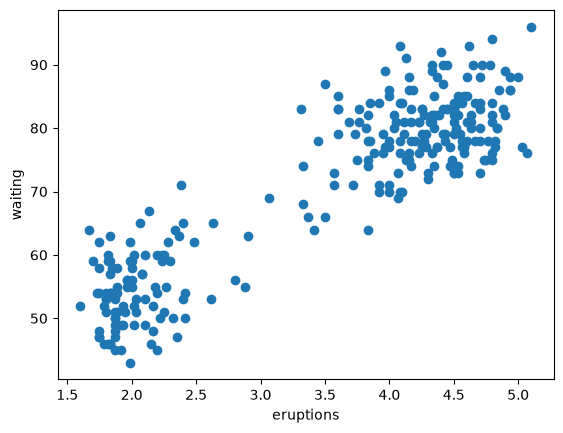

In [7]:
plt.scatter(df['eruptions'],df['waiting'])
plt.xlabel("eruptions")
plt.ylabel("waiting")

In [8]:
X = df.eruptions
y = df.waiting

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

# X_train is the subset of input colum which use for tarinig the model
#Y_train  : use to test or evaluate the model which is output of the X_train 

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   eruptions  272 non-null    float64
 1   waiting    272 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.4 KB


In [11]:
X_train.head()

33     4.033
184    2.033
142    4.533
197    4.366
37     4.833
Name: eruptions, dtype: float64

In [12]:
X_train.info()

<class 'pandas.Series'>
Index: 217 entries, 33 to 102
Series name: eruptions
Non-Null Count  Dtype  
--------------  -----  
217 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB


In [13]:
y_train.head()

33     80
184    51
142    82
197    77
37     80
Name: waiting, dtype: int64

In [14]:
y_train.info()

<class 'pandas.Series'>
Index: 217 entries, 33 to 102
Series name: waiting
Non-Null Count  Dtype
--------------  -----
217 non-null    int64
dtypes: int64(1)
memory usage: 3.4 KB


In [15]:
from sklearn.linear_model import LinearRegression 

# null hypo  : predicctor X and Y are correalted with each other  :  X does not influence Y  : line looklike y = 0  , x = somthing  X  and Y are parlled  :  Tan is  0 
# in realtion of X and Y they do not depend on eacch other  

m1=  LinearRegression()
X_train = np.array(X_train).reshape(-1,1)

m1.fit(X_train,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.78]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33.07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[17.29]


In [16]:


m1.coef_

array([10.78099868])

In [17]:

m1.intercept_

np.float64(33.07006162374168)

In [18]:
# dgree of freedom  = 1  :  model give coeff and intescpts  so total  = 2 so  df = n -1  : 1

In [19]:
m1.score(X_train,y_train) #r_squr indicate the % of vairation explain by the model 

0.8262346542339201

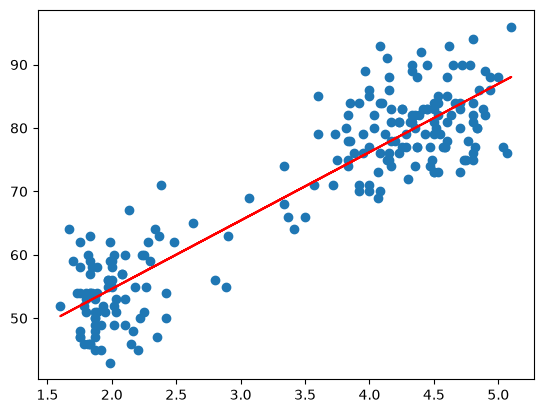

In [20]:
plt.scatter(X_train,y_train)
plt.plot(X_train,m1.predict(X_train),'r')

In [21]:
# 1. Definition: The residual is the difference between the actual value and the predicted value (Actual - Predicted).
# 2. Normality: Residuals should be normally distributed for reliable hypothesis testing and confidence intervals.
# 3. Mean: The mean (average) value of OLS residuals is mathematically guaranteed to be exactly 0 (if an intercept is included).
# 4. Correlation: Residuals must be completely uncorrelated (correlation = 0) with both the independent variables and the predicted values.


In [22]:

y_pred_test = m1.predict(np.array(X_test).reshape(-1,1))

In [23]:
y_pred_test

array([79.42835596, 58.04963557, 71.88165689, 81.5845557 , 70.80355702,
       86.25272813, 81.5845557 , 68.83063426, 52.47585925, 80.15068288,
       73.68208367, 80.68973281, 79.07258301, 77.27215623, 82.47937859,
       75.8275024 , 77.08887925, 83.01842853, 76.73310629, 57.14403168,
       79.07258301, 77.45543321, 74.39362958, 82.30688261, 80.86222879,
       79.9674059 , 70.26450708, 83.38498248, 72.77647978, 81.94032866,
       80.68973281, 55.3543859 , 79.78412892, 76.19405636, 71.52588393,
       83.74075544, 61.28393518, 83.74075544, 80.68973281, 52.65913623,
       71.88165689, 73.68208367, 82.47937859, 78.88930603, 82.30688261,
       58.94445846, 56.78825873, 53.90973208, 85.00213228, 53.37068215,
       56.43248577, 58.94445846, 78.16697912, 56.78825873, 83.01842853])

In [24]:
y_test

30     73
116    50
79     83
127    82
196    87
137    86
209    83
45     83
158    53
247    82
183    83
269    90
227    78
82     70
165    76
194    77
226    78
146    80
104    81
60     59
221    82
267    81
46     64
42     84
185    78
9      85
22     78
199    78
109    81
24     74
113    79
68     65
144    76
224    78
252    73
6      88
120    53
67     78
119    87
118    59
25     83
125    81
244    85
19     79
77     78
216    53
90     60
208    49
93     78
180    55
15     52
152    65
232    86
250    54
115    81
Name: waiting, dtype: int64

In [25]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='faithful')

In [26]:
x = df.waiting
y = df.eruptions

In [27]:


x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=20)

x_train = sm.add_constant(x_train)
mod1 = sm.OLS(y_train,x_train).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     871.7
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           1.37e-77
Time:                        13:03:19   Log-Likelihood:                -160.39
No. Observations:                 217   AIC:                             324.8
Df Residuals:                     215   BIC:                             331.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9119      0.185    -10.326      0.0

In [28]:
# two tailed test :  null Hypo h0 :is m =0
#            Alt hypo hA :  is m != 0  
#  p =  0 
#  becouse p < 0.05 we reject the  null hypoo 
# ?concliution  would be m != 0 or diffrence between zero and 0.759 cannot be ignore

In [29]:
# 1. Reshape your test data
# x_test_reshaped = np.array(x_test).reshape(-1, 1)

# 2. Add the constant column to match the training data shape
x_test_with_constant = sm.add_constant(x_test)

# 3. Run the prediction
y_pred_test2 = mod1.predict(x_test_with_constant)

In [30]:
y_pred_test2

72     4.083201
132    2.337782
129    4.917967
29     4.083201
87     4.159089
211    4.159089
108    4.614416
163    4.007314
20     1.958343
264    1.351241
171    2.413670
220    1.882456
156    4.234977
249    3.703762
181    3.931426
34     3.703762
99     4.310865
169    5.145630
13     1.654792
210    3.476099
212    1.806568
241    1.654792
150    3.931426
89     4.614416
149    2.110119
59     4.234977
53     4.159089
175    4.234977
228    3.400211
214    2.944885
16     2.793109
62     1.730680
193    4.462640
179    3.703762
90     2.641333
194    3.931426
168    2.034231
197    3.931426
267    4.234977
28     4.007314
98     1.958343
233    1.882456
117    4.538528
216    2.110119
250    2.186007
63     4.310865
174    4.234977
261    4.462640
135    4.310865
254    4.766191
112    4.842079
109    4.234977
122    3.931426
77     4.007314
247    4.310865
dtype: float64

In [31]:
y_test

72     4.500
132    2.800
129    4.650
29     4.433
87     4.517
211    4.700
108    4.850
163    3.833
20     1.800
264    1.983
171    2.083
220    1.867
156    4.500
249    4.350
181    4.583
34     3.833
99     4.900
169    4.617
13     1.750
210    2.383
212    1.867
241    2.350
150    5.033
89     4.000
149    1.800
59     4.317
53     4.833
175    4.333
228    3.917
214    3.417
16     1.750
62     1.750
193    4.100
179    4.167
90     2.200
194    3.966
168    1.933
197    4.366
267    4.117
28     3.850
98     1.867
233    2.217
117    4.600
216    2.400
250    2.200
63     4.800
174    4.167
261    4.533
135    4.383
254    4.150
112    4.900
109    3.683
122    4.250
77     4.567
247    4.367
Name: eruptions, dtype: float64

In [32]:


# 1. Unexplained Variation (UV) / Residual Sum of Squares (RSS)
# Measures the variation that the model failed to explain on the test data.
# Note: y_test must be used here, NOT y_train.
UV = np.sum((y_test - y_pred_test2) ** 2)

# 2. Total Variation (TV) / Total Sum of Squares (TSS)
# Measures the total inherent variation in the actual test baseline.
# Note: Based on the average of the test data.
TV = np.sum((y_test - np.mean(y_test)) ** 2)

# 3. Explained Variation (EV) / Model Sum of Squares (MSS)
# The amount of variation successfully captured by your regression model.
EV = TV - UV

# 4. R-squared (R²) Value
# The proportion of total variation in the test data explained by the model.
# Scale ranges from 0 (poor fit) to 1 (perfect fit).
r2_score = EV / TV


# UV - unexplained variation
# TV - total variation
# EV - explained variation 

In [33]:
r2_score

np.float64(0.8447183619443297)

In [34]:
(EV/1 )/ (UV/215)

np.float64(1169.580963287623)

In [35]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='stackloss')
x = df.drop('StackLoss', axis=1)
y = df.StackLoss
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=20)

x_train = sm.add_constant(x_train,prepend=False)
mod1 = sm.OLS(y_train,x_train).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     33.46
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           4.14e-06
Time:                        13:03:19   Log-Likelihood:                -41.238
No. Observations:                  16   AIC:                             90.48
Df Residuals:                      12   BIC:                             93.57
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.7337      0.169      4.346      0.0

In [36]:
# h0 : coeff of air flow : == 0 

# becouse p < 0.05 : rejet the h0        






In [37]:

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='stackloss')
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss',axis=1), df.StackLoss, test_size=0.2, random_state=20)

from sklearn.linear_model import LinearRegression
regr=LinearRegression()
regr.fit(x_train,y_train)

regr.coef_
regr.intercept_

np.float64(-32.30943576204309)

In [38]:
mydata = pd.DataFrame([[65,20,85],[70,25,90],[75,20,80]], columns=x_train.columns)

regr.predict(mydata)

array([20.14957103, 29.43967692, 28.84952946])

In [39]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)











In [40]:
from sklearn.linear_model import LinearRegression
regr=LinearRegression()
regr.fit(x_train,y_train)

regr.coef_
regr.intercept_

mydata = pd.DataFrame([[65,20,85],[70,25,90],[75,20,80]], columns=['AirFlow','WaterTemp','AcidConc'])
mydata = scaler.transform(mydata)
regr.predict(mydata)

array([20.14957103, 29.43967692, 28.84952946])

In [41]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='salaries')
df = df[['yrs_service', 'gender','salary']]

gender_dummy = pd.get_dummies(df.gender,drop_first=True).astype(int)
df = df.drop('gender', axis=1)
df = pd.concat([df,gender_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(df.drop('salary',axis=1), df.salary, test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train,prepend=False)
mod1 = sm.OLS(y_train,x_train).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     21.52
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           1.75e-09
Time:                        13:03:19   Log-Likelihood:                -3698.4
No. Observations:                 317   AIC:                             7403.
Df Residuals:                     314   BIC:                             7414.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service   701.6382    125.946      5.571      

In [42]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [43]:
## Read the dataset
df=pd.read_csv(''"height-weight (1).csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

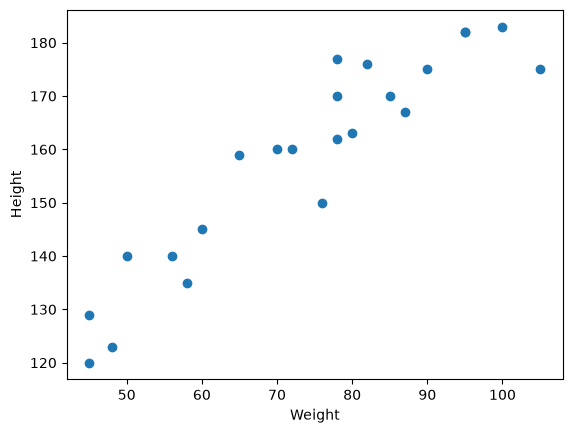

In [44]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [45]:
## divide our dataset into independent and dependent edatures
X=df[['Weight']] ##independent feature   :  input 
y=df['Height'] ##dependent feature  : output 

In [46]:
## Train test split
from sklearn.model_selection import train_test_split

In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [48]:
X.shape

(23, 1)

In [49]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [50]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler

In [51]:
scaler=StandardScaler()

In [52]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [53]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

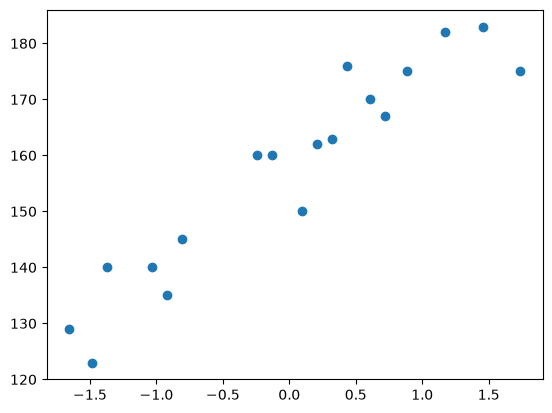

In [54]:
plt.scatter(X_train,y_train)

In [55]:
## Train the Simple Linear Regression Model
from sklearn.linear_model import LinearRegression

In [56]:
regressor=LinearRegression()

In [57]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,157.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.24]


In [58]:
print("The slope or coefficient of weight is ",regressor.coef_)
print("Intercept:",regressor.intercept_)

The slope or coefficient of weight is  [17.03440872]
Intercept: 157.5


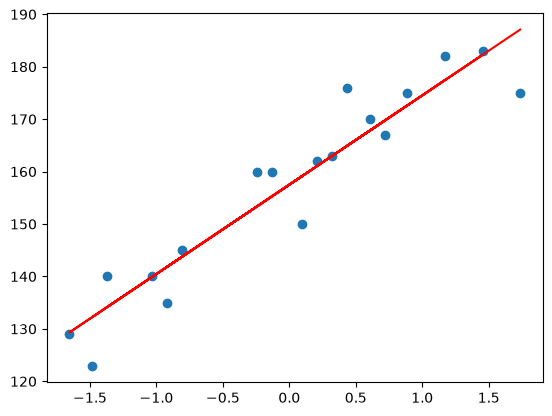

In [59]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [60]:
y_pred_test=regressor.predict(X_test)

In [61]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

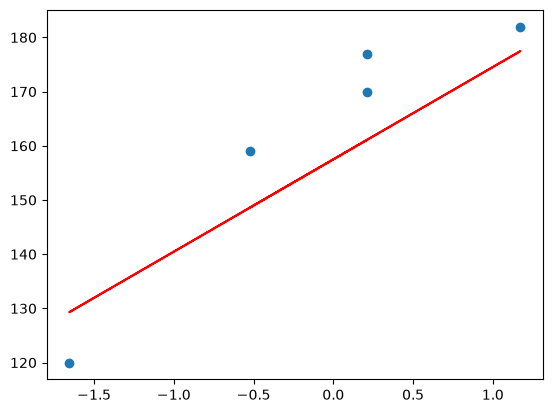

In [62]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

## Performance Metrics

## MSE,MAE,RMSE
## R square and adjusted R square

In [63]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [64]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051654
9.822657814519227
10.477400726827076


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [65]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)

In [66]:
score

0.7769869860423441

## Adjusted R Square

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [67]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231254

In [68]:
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,157.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.24]


In [69]:
## new data point weight is 80

scaled_weight=scaler.transform([[80]])
scaled_weight

c:\Users\praja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [70]:
scaled_weight[0]

array([0.32350772])

In [71]:
print("The height prediction for weight 80 kg is :",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is : [163.01076266]


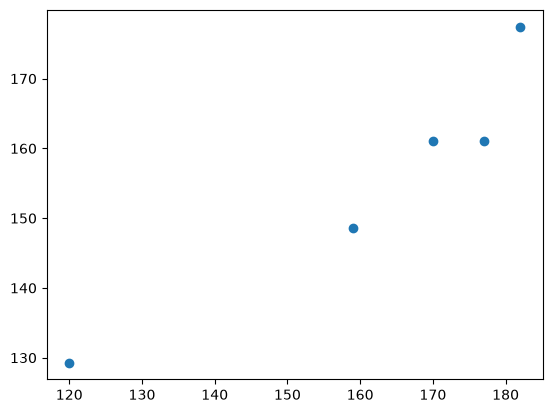

In [72]:
## Assumptions
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [73]:
## Residuals
residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\praja\AppData\Local\Temp\ipykernel_20768\2747191050.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

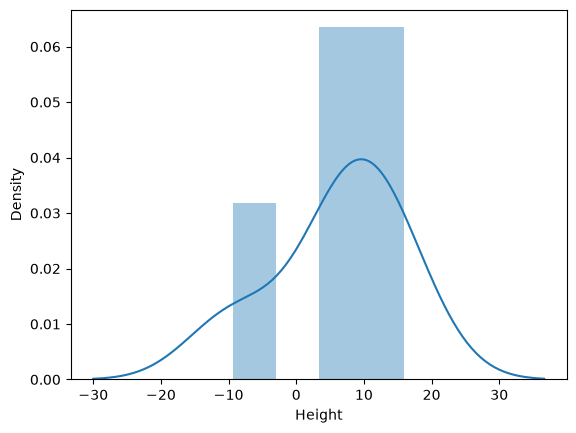

In [74]:
## plot this residuals
import seaborn as sns
sns.distplot(residuals,kde=True)

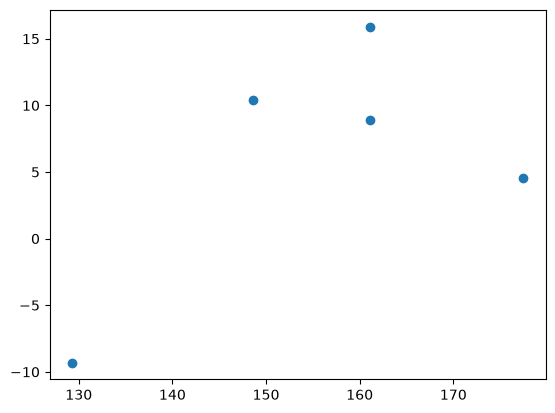

In [75]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)